# EDA Weather / Flights

## Intro Weather
This part of the notebook is analyzing the weather data for the timeperiod of Sep 2025 to Nov 2025 and compare weather stats from storm period to non storm period. 

### Question 1:
Does the weather data reflect the weather event at respective stations (JFK, LGD,EWR)?


###Methodology:
Analyse weather stats over timeframe and see if the affected period shows deviations from rest of the time. 

In [30]:
#imports

import pandas as pd
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string
from scipy.stats import ttest_ind

In [2]:
# Let's load values from the .env file
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

In [3]:
# Now building the URL with the values from the .env file

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

# without specifying the schema default connection is to the schema `public`
# url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

In [4]:
engine = create_engine(url, echo=False)

In [5]:
my_schema = 's_danieljaeckel' # update it to your schema

with engine.begin() as conn: 
    result = conn.execute(text(f'SET search_path TO {my_schema};'))

In [20]:
import pandas as pd

query = "SELECT * FROM staging_weather_daily"

df_weather = pd.read_sql(query, engine)

In [23]:
df_weather

,airport_code,station_id,date,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,max_snow_mm,avg_wind_direction,avg_wind_speed_kmh,wind_peakgust_kmh,avg_pressure_hpa,sun_minutes
0,JFK,74486,2025-09-01,20.1,15.0,26.1,0.0,0,None,12.1,NaN,1023.6,None
1,JFK,74486,2025-09-02,19.6,15.0,24.4,0.0,0,None,12.4,NaN,1020.5,None
2,JFK,74486,2025-09-03,19.3,15.0,23.9,0.0,0,None,11.6,NaN,1014.7,None
3,JFK,74486,2025-09-04,21.2,17.2,25.0,2.8,0,None,22.0,NaN,1012.3,None
4,JFK,74486,2025-09-05,22.5,18.9,27.2,6.9,0,None,20.1,NaN,1013.4,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,EWR,72502,2025-11-26,14.0,8.9,16.1,3.6,0,None,16.2,NaN,1008.7,None
269,EWR,72502,2025-11-27,6.0,1.7,8.9,0.0,0,None,24.8,NaN,1012.8,None
270,EWR,72502,2025-11-28,3.1,-0.6,7.2,0.0,0,None,29.2,NaN,1015.5,None
271,EWR,72502,2025-11-29,3.2,-1.1,7.8,0.0,0,None,16.8,NaN,1030.1,None


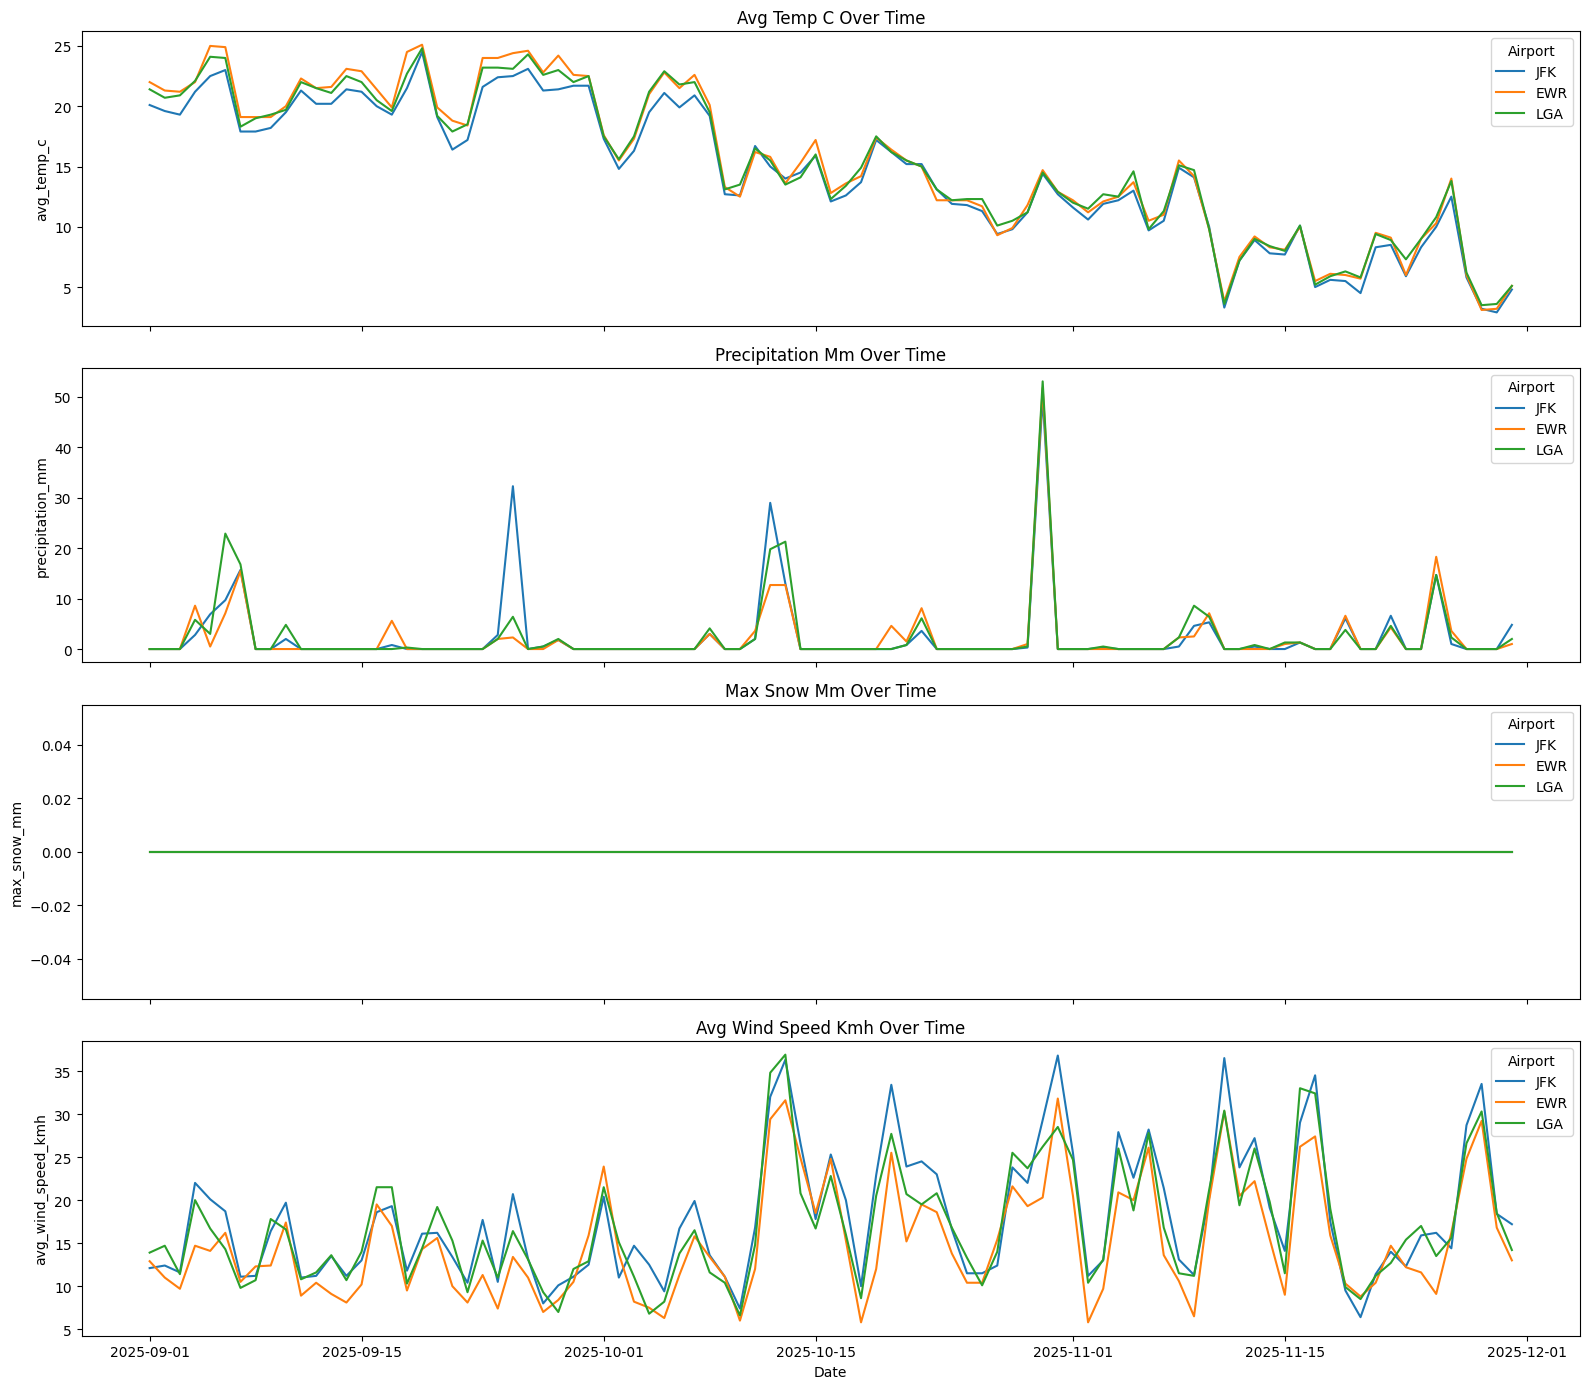

In [24]:
#plotting over time

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure datetime
df_weather["date"] = pd.to_datetime(df_weather["date"])

# Sort for proper line plotting
df_weather = df_weather.sort_values("date")

weather_vars = [
    "avg_temp_c",
    "precipitation_mm",
    "max_snow_mm",
    "avg_wind_speed_kmh"
]

# Create 4 vertical subplots
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(16, 14), sharex=True)

for ax, var in zip(axes, weather_vars):
    
    sns.lineplot(
        data=df_weather,
        x="date",
        y=var,
        hue="airport_code",
        ax=ax
    )
    
    ax.set_title(f"{var.replace('_', ' ').title()} Over Time")
    ax.set_ylabel(var)
    ax.legend(title="Airport")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [ ]:
#analyze changes in prec in more detail

# Define periods
baseline_start = "2025-09-01"
baseline_end   = "2025-10-14"

storm_start = "2025-10-15"
storm_end   = "2025-11-15"

baseline = df_weather[
    (df_weather["date"] >= baseline_start) &
    (df_weather["date"] <= baseline_end)
]

storm = df_weather[
    (df_weather["date"] >= storm_start) &
    (df_weather["date"] <= storm_end)
]

# Compare precipitation means per airport
baseline_mean = baseline.groupby("airport_code")["precipitation_mm"].mean()
storm_mean = storm.groupby("airport_code")["precipitation_mm"].mean()

comparison_prec = pd.DataFrame({
    "baseline_avg_mm": baseline_mean,
    "storm_avg_mm": storm_mean
})

comparison_prec["absolute_change_mm"] = (
    comparison_prec["storm_avg_mm"] - comparison_prec["baseline_avg_mm"]
)

comparison_prec["percent_change"] = (
    comparison_prec["absolute_change_mm"] / comparison_prec["baseline_avg_mm"] * 100
)

# ✅ ROUND HERE
comparison_prec = comparison_prec.round({
    "baseline_avg_mm": 2,
    "storm_avg_mm": 2,
    "absolute_change_mm": 2,
    "percent_change": 1
})

comparison_prec

,baseline_avg_mm,storm_avg_mm,absolute_change_mm,percent_change
airport_code,,,,
EWR,1.71,2.50,0.78,45.7
JFK,2.78,2.05,-0.73,-26.1
LGA,2.54,2.51,-0.03,-1.0


In [32]:
for airport in df_weather["airport_code"].unique():
    
    base_vals = baseline[baseline["airport_code"] == airport]["precipitation_mm"].dropna()
    storm_vals = storm[storm["airport_code"] == airport]["precipitation_mm"].dropna()
    
    stat, p = ttest_ind(base_vals, storm_vals, equal_var=False)
    
    print(f"{airport}: p-value = {round(p, 4)}")

JFK: p-value = 0.7016
EWR: p-value = 0.653
LGA: p-value = 0.9891


In [28]:
#analyze changes in windspeed in more detail

# Define periods
baseline_start = "2025-09-01"
baseline_end   = "2025-10-14"

storm_start = "2025-10-15"
storm_end   = "2025-11-15"

baseline = df_weather[
    (df_weather["date"] >= baseline_start) &
    (df_weather["date"] <= baseline_end)
]

storm = df_weather[
    (df_weather["date"] >= storm_start) &
    (df_weather["date"] <= storm_end)
]

# Compare precipitation means per airport
baseline_mean = baseline.groupby("airport_code")["avg_wind_speed_kmh"].mean()
storm_mean = storm.groupby("airport_code")["avg_wind_speed_kmh"].mean()

comparison_wind = pd.DataFrame({
    "baseline_avg_kmh": baseline_mean,
    "storm_avg_kmh": storm_mean
})

comparison_wind["absolute_change_kmh"] = (
   comparison_wind["storm_avg_kmh"] - comparison_wind["baseline_avg_kmh"]
)

comparison_wind["percent_change"] = (
    comparison_wind["absolute_change_kmh"] / comparison_wind["baseline_avg_kmh"] * 100
)

# ✅ ROUND HERE
comparison_wind = comparison_wind.round({
    "baseline_avg_kmh": 2,
    "storm_avg_kmh": 2,
    "absolute_change_kmh": 2,
    "percent_change": 1
})

comparison_wind

,baseline_avg_kmh,storm_avg_kmh,absolute_change_kmh,percent_change
airport_code,,,,
EWR,13.00,17.17,4.17,32.1
JFK,15.30,21.25,5.95,38.9
LGA,14.64,19.38,4.74,32.4


In [33]:
for airport in df_weather["airport_code"].unique():
    
    base_vals = baseline[baseline["airport_code"] == airport]["avg_wind_speed_kmh"].dropna()
    storm_vals = storm[storm["airport_code"] == airport]["avg_wind_speed_kmh"].dropna()
    
    stat, p = ttest_ind(base_vals, storm_vals, equal_var=False)
    
    print(f"{airport}: p-value = {round(p, 4)}")

JFK: p-value = 0.0004
EWR: p-value = 0.0061
LGA: p-value = 0.0015


### Interpretation Weather 

The precipitation stats show an increase for rainfall for EWR, JFK and LGD both experienced less rainfall during the storm. Also changes were not statistically significant and can therefore be seen as minor impact. 

Still  we can see a rise in the avg windnd speed per aiport during the storm period. We see an increase of more than 30% increase in wind speed during the period of the storm. T Test shows statistical sigifinacne in difference for all 3 airports. Therefore we can reject H1 and assume with an error of 5% that the measured wind speed for the storm period statistically differ from the comparison time. 


## Intro Flights
This part of the notebook is analyzing the flights data for the time period of Sep 2025 to Nov 2025 and compare flights stats from storm period to non storm period. 

### Question 1:
Does the flights data reflect the weather event at respective stations (JFK, LGD,EWR)?


Methodology:
Analyse flight stats (flghts, cancellations, deviations) over timeframe and see if the affected period shows deviations from rest of the time. 

In [34]:
query = "SELECT * FROM staging_flights_enriched"

df_flights = pd.read_sql(query, engine)

/var/folders/r6/zz5ts5yd3w953cvv8dsdndrr0000gn/T/ipykernel_3382/3080110401.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


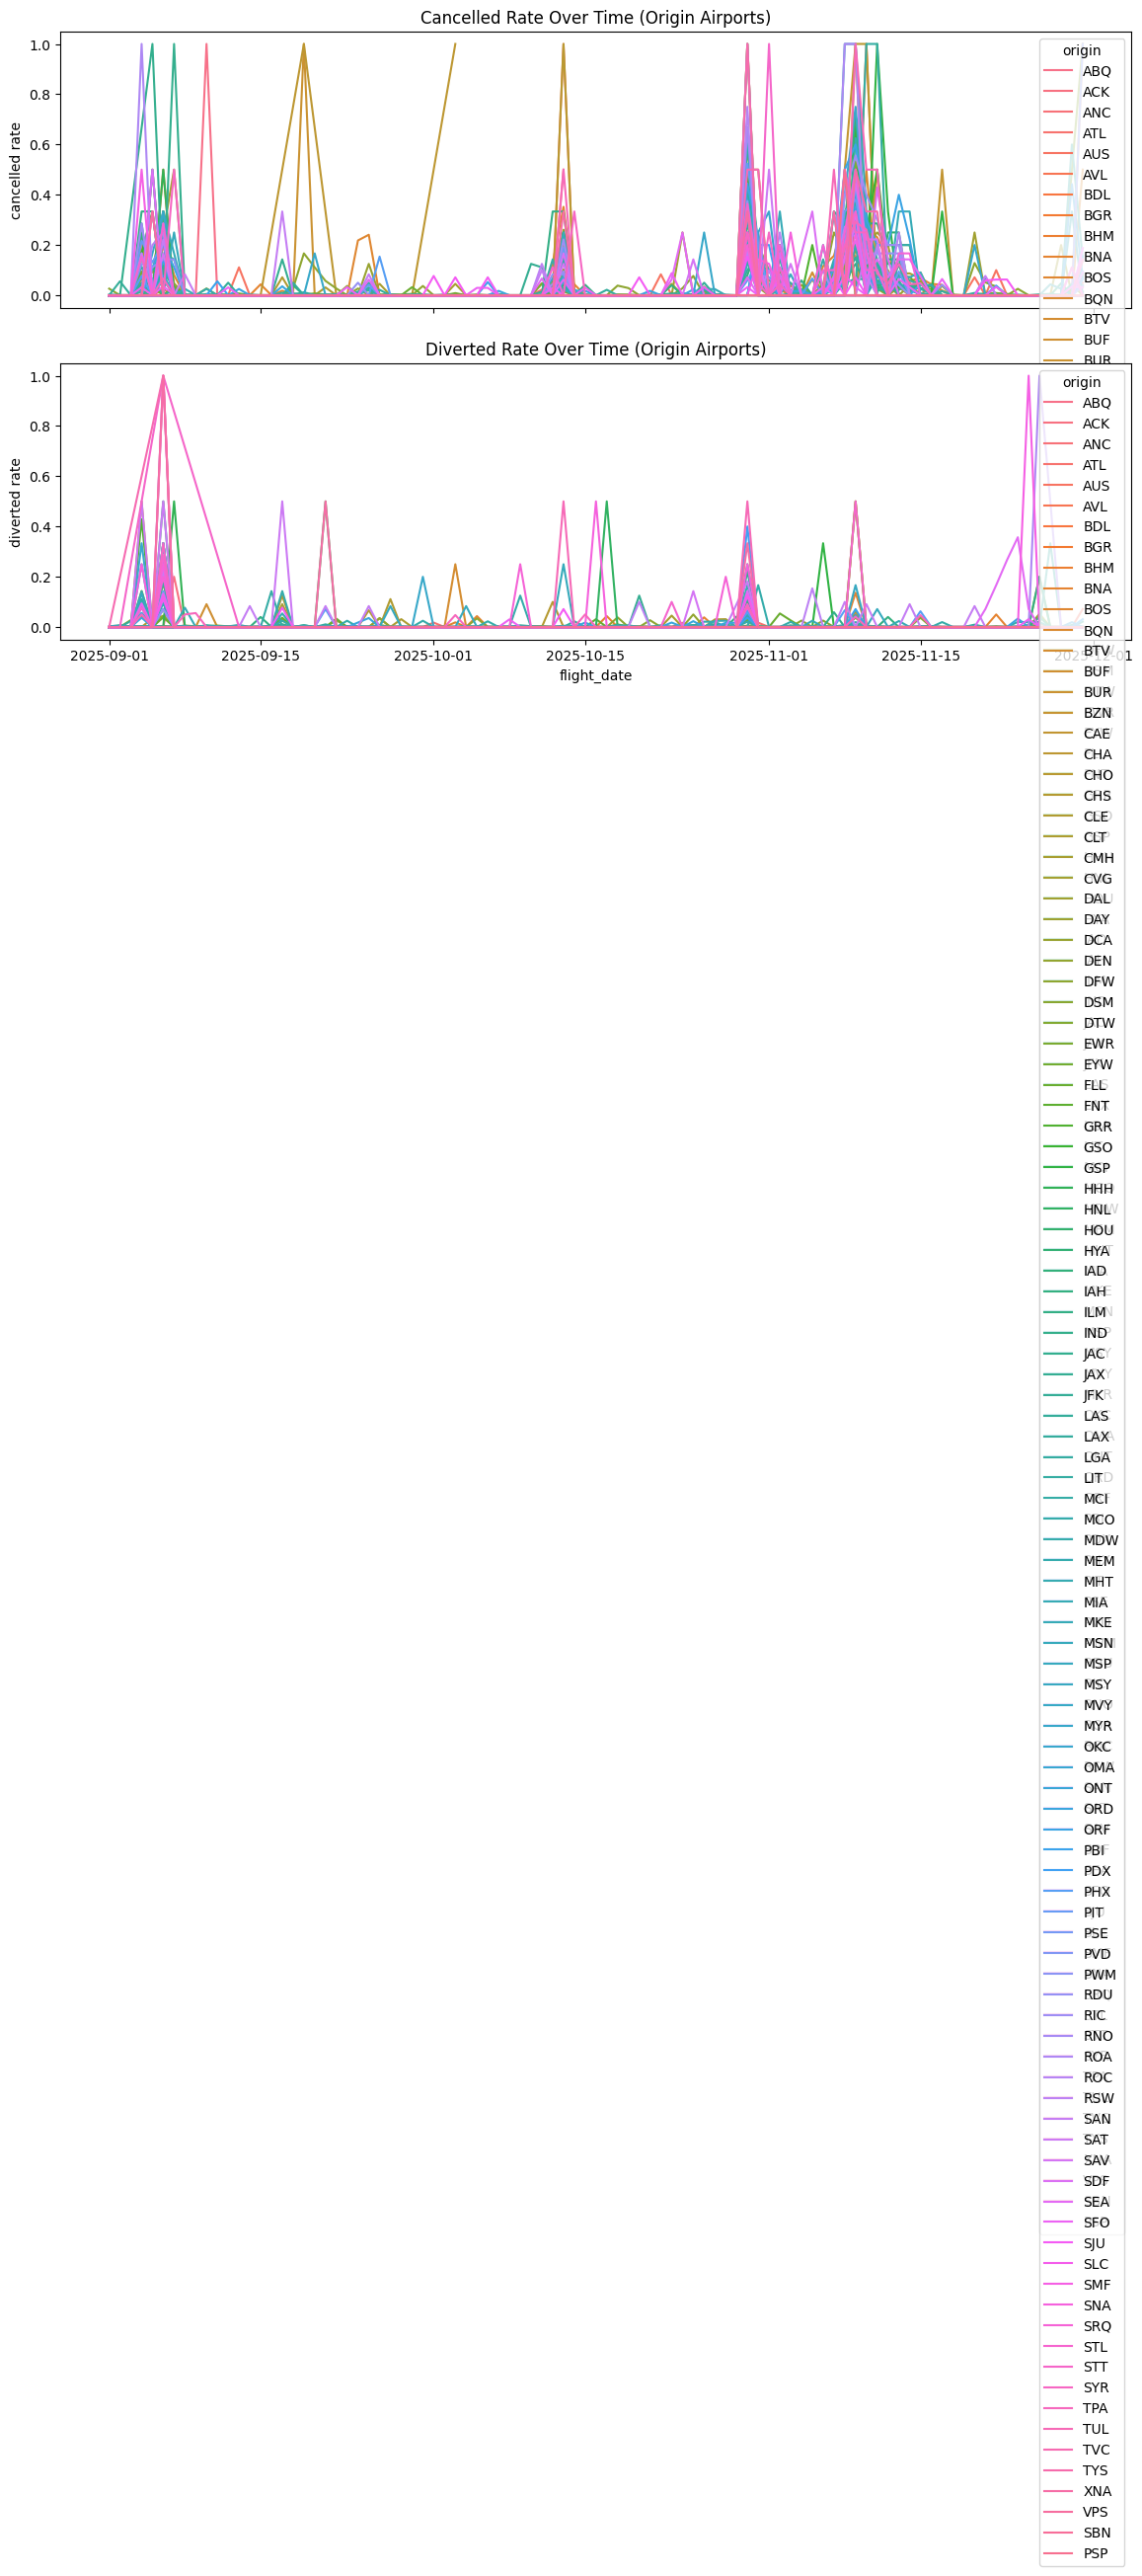

In [46]:
event_df = df_flights.groupby(
    ["flight_date", "origin"]
)[["cancelled", "diverted"]].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

event_vars = ["cancelled", "diverted"]

for ax, var in zip(axes, event_vars):

    sns.lineplot(
        data=event_df,
        x="flight_date",
        y=var,
        hue="origin",
        ax=ax
    )

    ax.set_title(f"{var.title()} Rate Over Time (Origin Airports)")
    ax.set_ylabel(f"{var} rate")

plt.tight_layout()
plt.show()